In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm

plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = [cm.viridis(i) for i in np.linspace(0, 0.85, 5)]

### Data Dictionary: Auction Lead Analysis

| Column name | Data type | Description |
| :--- | :--- | :--- |
| **auction_id** | `int64` | Unique identifier for each specific auction event. |
| **bid** | `float64` | The value of the specific bid entered by the bidder. |
| **bid_time** | `float64` | Time elapsed (in days) since the auction started. |
| **bidder** | `object` | Anonymized username or ID of the person placing the bid. |
| **bidder_rate**| `float64` | The feedback rating of the bidder (proxy for experience). |
| **open_bid** | `float64` | The starting price set by the seller. |
| **hammer_price** | `float64` | The final selling price of the item (the winning bid). |
| **item** | `object` | Category or name of the object being auctioned (e.g., Cartier wristwatch). |
| **auction_type** | `object` | The duration of the auction (e.g., "3 day auction"). |
| **duration_days** | `int/float`| **(Engineered)** The total length of the auction extracted as a numeric value. |
| **relative_bid_time**| `float64` | **(Engineered)** Bid time as a % of total duration (0.0 = start, 1.0 = end). |
| **bid_increment** | `float64` | **(Engineered)** The "jump" in price from the previous bid in that auction. |
| **is_winner** | `bool` | **(Engineered)** True if this specific row represents the winning bid. |
| **is_snipe** | `bool` | **(Engineered)** True if the bid was placed in the final 5% of the auction time. |

In [31]:
auction_df = pd.read_csv("../data/auction.csv")

auction_df.head()

,auctionid,bid,bidtime,bidder,bidderrate,openbid,price,item,auction_type
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
3,1638893549,150.0,2.601076,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
4,1638893549,177.5,2.909826,eli.flint@flightsafety.co,4.0,99.0,177.5,Cartier wristwatch,3 day auction


In [32]:
print(auction_df.shape)
auction_df.dtypes

(10681, 9)


auctionid         int64
bid             float64
bidtime         float64
bidder              str
bidderrate      float64
openbid         float64
price           float64
item                str
auction_type        str
dtype: object

In [33]:
print(f"Total duplicates: {auction_df.duplicated().sum()}")

print("\nTotal missing values:\n\n", auction_df.isna().sum())

Total duplicates: 0

Total missing values:

 auctionid        0
bid              0
bidtime          0
bidder          16
bidderrate      11
openbid          0
price            0
item             0
auction_type     0
dtype: int64


In [34]:
auction_df_clean = auction_df.copy()

auction_df_clean["bidder"] = auction_df_clean["bidder"].fillna("Unknown")

# Using 0 for bidderrate (assuming new/guest user)
auction_df_clean["bidderrate"] = auction_df_clean["bidderrate"].fillna(0)

print("Total missing values:\n\n", auction_df_clean.isna().sum())

Total missing values:

 auctionid       0
bid             0
bidtime         0
bidder          0
bidderrate      0
openbid         0
price           0
item            0
auction_type    0
dtype: int64


In [35]:
auction_df_clean = auction_df_clean.rename(columns = {
    "auctionid": "auction_id",
    "bidtime": "bid_time",
    "bidderrate": "bidder_rate", 
    "openbid": "open_bid",
    "price": "hammer_price"
})

auction_df_clean.head()

,auction_id,bid,bid_time,bidder,bidder_rate,open_bid,hammer_price,item,auction_type
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
3,1638893549,150.0,2.601076,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
4,1638893549,177.5,2.909826,eli.flint@flightsafety.co,4.0,99.0,177.5,Cartier wristwatch,3 day auction


In [36]:
print(auction_df_clean["item"].unique())
print(auction_df_clean["auction_type"].unique())

<StringArray>
['Cartier wristwatch', 'Palm Pilot M515 PDA', 'Xbox game console']
Length: 3, dtype: str
<StringArray>
['3 day auction', '5 day auction', '7 day auction']
Length: 3, dtype: str


In [37]:
auction_df_clean["auction_duration_days"] = auction_df_clean["auction_type"].str.extract(r"(\d+)").astype(int)

auction_df_clean["relative_bid_time"] = auction_df_clean["bid_time"] / auction_df_clean["auction_duration_days"]

auction_df_clean.head(3)

,auction_id,bid,bid_time,bidder,bidder_rate,open_bid,hammer_price,item,auction_type,auction_duration_days,relative_bid_time
0,1638893549,175.0,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.743650
1,1638893549,100.0,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.866705
2,1638893549,120.0,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction,3,0.866937


In [38]:
# Adding bid momentum for each auction
auction_df_clean = auction_df_clean.sort_values(["auction_id", "bid_time"])
auction_df_clean["bid_increment"] = auction_df_clean.groupby("auction_id")["bid"].diff().fillna(0)


# Flagging winner
auction_df_clean["is_winner"] = auction_df_clean["bid"] == auction_df_clean["hammer_price"]


# A bid is a snipe if it happens in the final 5% of the auction 
auction_df_clean["is_snipe"] = auction_df_clean["relative_bid_time"] > 0.95

In [39]:
snipe_percentage = auction_df_clean["is_snipe"].mean() * 100
print(f"Percentage of bids that are 'Snipes': {snipe_percentage:.2f}%")

Percentage of bids that are 'Snipes': 32.10%


In [40]:
auction_df_clean.describe()

,auction_id,bid,bid_time,bidder_rate,open_bid,hammer_price,auction_duration_days,relative_bid_time,bid_increment
count,1.068100e+04,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000,10681.000000
mean,4.136148e+09,207.586109,3.979628,31.903848,52.246256,335.043589,5.939612,0.670505,11.574572
std,2.489918e+09,323.037396,2.353386,120.536308,168.453245,433.566009,1.584867,0.339510,68.624678
min,1.638844e+09,0.010000,0.000567,-4.000000,0.010000,26.000000,3.000000,0.000081,-1080.000000
25%,3.015329e+09,72.000000,1.949931,1.000000,1.000000,186.510000,5.000000,0.361319,0.000000
50%,3.020526e+09,140.000000,4.140833,5.000000,4.990000,228.490000,7.000000,0.821879,5.000000
75%,8.212136e+09,210.000000,6.448060,21.000000,50.000000,255.000000,7.000000,0.974873,15.000000
max,8.215611e+09,5400.000000,6.999990,3140.000000,5000.000000,5400.000000,7.000000,0.999999,1150.000000


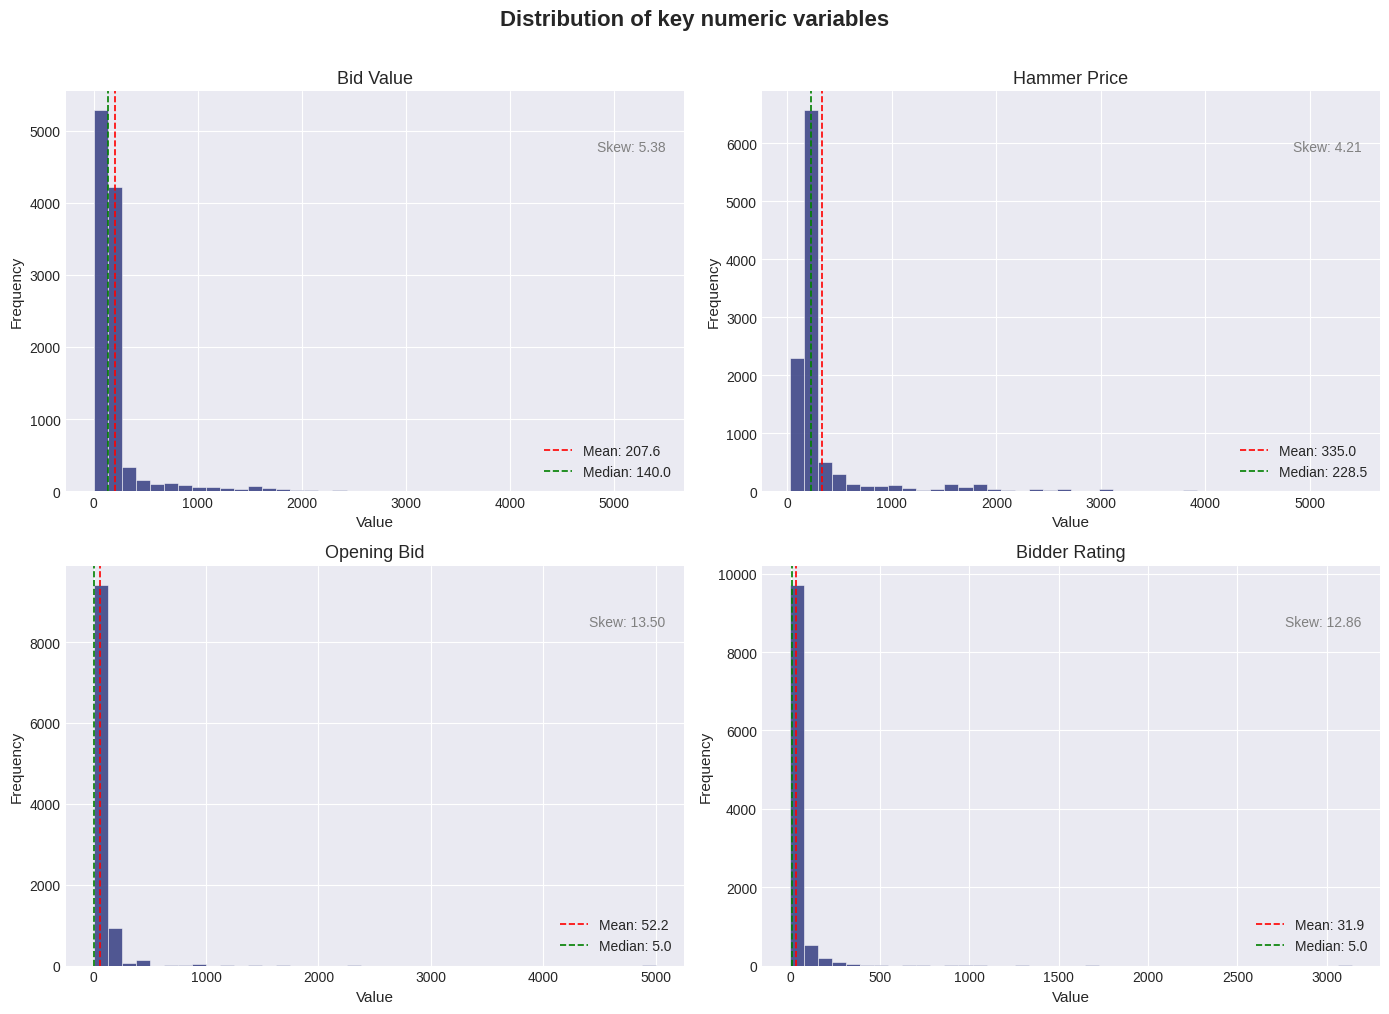

In [41]:
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("Distribution of key numeric variables", fontsize=16, fontweight="bold", y=1.01)

cols = {
    "bid": "Bid Value",
    "hammer_price": "Hammer Price",
    "open_bid": "Opening Bid",
    "bidder_rate": "Bidder Rating"
}

for ax, (col, label) in zip(axes.flatten(), cols.items()):
    data = auction_df_clean[col]

    ax.hist(data, bins=40, color=PALETTE[1], edgecolor="white", linewidth=0.4, alpha=0.9)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="green", linestyle="--", linewidth=1.2, label=f"Median: {data.median():.1f}")

    ax.set_title(label, fontsize=13)
    ax.set_xlabel("Value", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.legend(fontsize=10)

    skew = data.skew()
    ax.text(
        0.97, 0.85,
        f"Skew: {skew:.2f}",
        transform=ax.transAxes,
        ha="right", fontsize=10,
        color="gray"
    )

plt.tight_layout()
plt.savefig("../img/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

bid, hammer_price, and open_bid will show strong right skew, a small number of high-value items pulling the tail: most items cluster in a low-price range, but outliers drive disproportionate revenue.  

bidder_rate is heavily zero-inflated given null-fill strategy.

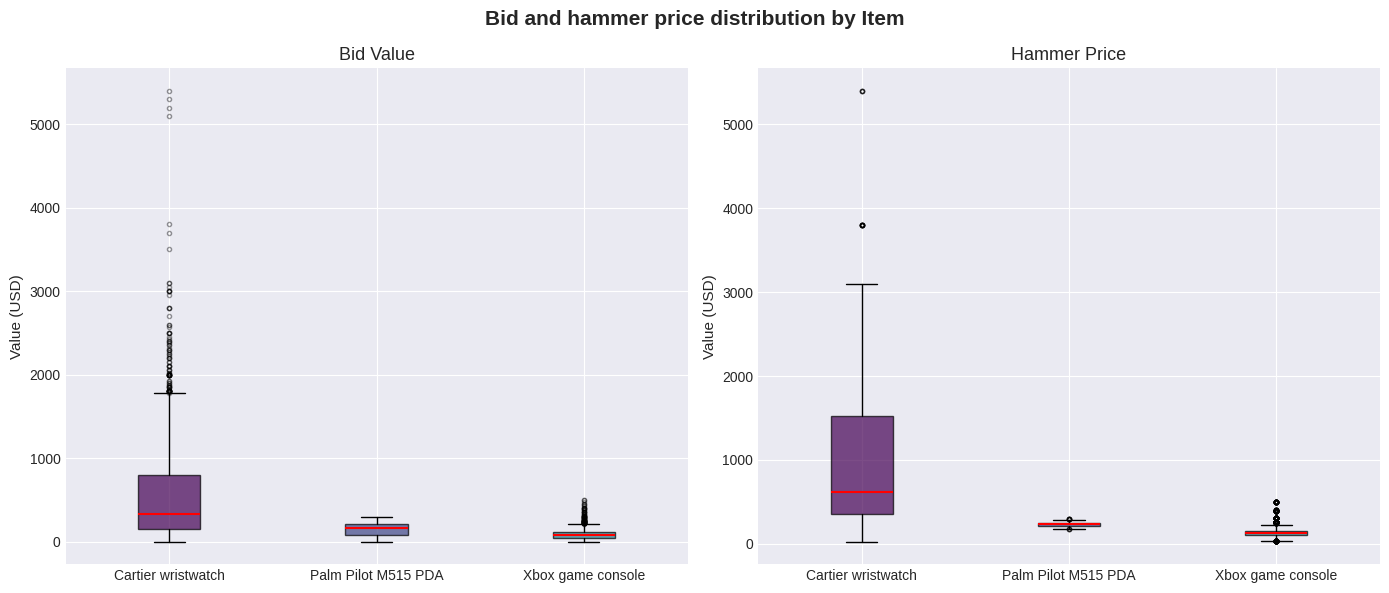

In [42]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Bid and hammer price distribution by Item", fontsize=15, fontweight="bold")

for ax, col, label in zip(axes, ["bid", "hammer_price"], ["Bid Value", "Hammer Price"]):
    data = [
        auction_df_clean[auction_df_clean["item"] == item][col].values
        for item in auction_df_clean["item"].unique()
    ]

    bp = ax.boxplot(
        data,
        tick_labels=auction_df_clean["item"].unique(),
        patch_artist=True,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        medianprops=dict(color="red", linewidth=1.5)
    )

    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(label, fontsize=13)
    ax.set_ylabel("Value (USD)", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.savefig("../img/02_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

The Cartier box sitting higher on the hammer price chart means the floor of a typical Cartier auction outcome is already above the ceiling of a typical Palm Pilot or Xbox sale. It's not just that Cartier has outliers, even its interquartile range doesn't overlap much with the other two items.
The bid value vs. hammer price comparison also reveals something subtle: Cartier's bid box is relatively compressed (median ~400) but the hammer price box is much taller and higher. That suggests competitive escalation, auctions starting modestly but getting driven up significantly by bidding wars. The Palm Pilot and Xbox show much tighter bid-to-hammer relationships, indicating more predictable, lower-competition outcomes.

Does Cartier also attract more bidders per auction, explaining that escalation?
Do Cartier auctions snipe more: are those outlier hammer prices driven by last-minute bids?
Is the realization ratio (hammer/open) highest for Cartier, confirming it as the highest "market heat" category?

In [43]:
auction_level_df = auction_df_clean.groupby("auction_id").apply(
    lambda g: pd.Series({
        # Auction identity
        "item":                   g["item"].iloc[0],
        "auction_type":           g["auction_type"].iloc[0],
        "auction_duration_days":  g["auction_duration_days"].iloc[0],

        # Pricing
        "open_bid":               g["open_bid"].iloc[0],
        "hammer_price":           g["hammer_price"].iloc[0],
        "realization_ratio":      g["hammer_price"].iloc[0] / g["open_bid"].iloc[0],

        # Bid volume
        "n_bids":                 len(g),
        "n_bidders":              g["bidder"].nunique(),
        "n_snipe_bids":           g["is_snipe"].sum(),
        "single_bidder_flag":     g["bidder"].nunique() == 1,

        # Bid increments
        "max_bid_increment":      g["bid_increment"].max(),
        "std_bid_increment":      g["bid_increment"].std(), # how erratic the bidding was

        # Bidder experience
        "mean_bidder_rate":       g["bidder_rate"].mean(),
        "max_bidder_rate":        g["bidder_rate"].max(),

        # Timing
        "first_bid_time":         g["bid_time"].min(),
        "active_window":          g["bid_time"].max() - g["bid_time"].min(),

        # Repeat bidders
        "n_repeat_bidders":       (g.groupby("bidder").size() > 1).sum(),

        # Winner profile
        "winner_sniped":          g.loc[g["is_winner"], "is_snipe"].values[0] if g["is_winner"].any() else np.nan,
        "winner_bidder_rate":     g.loc[g["is_winner"], "bidder_rate"].values[0] if g["is_winner"].any() else np.nan
    })
).reset_index()

auction_level_df.head()

,auction_id,item,auction_type,auction_duration_days,open_bid,hammer_price,realization_ratio,n_bids,n_bidders,n_snipe_bids,single_bidder_flag,max_bid_increment,std_bid_increment,mean_bidder_rate,max_bidder_rate,first_bid_time,active_window,n_repeat_bidders,winner_sniped,winner_bidder_rate
0,1638843936,Cartier wristwatch,7 day auction,7,500.0,1625.0,3.250000,7,5,2,False,900.0,359.935510,38.428571,181.0,0.478368,6.414745,1,True,5.0
1,1638844284,Cartier wristwatch,7 day auction,7,200.0,500.0,2.500000,2,2,0,False,275.0,194.454365,16.500000,33.0,1.237419,0.014988,0,False,33.0
2,1638844464,Cartier wristwatch,7 day auction,7,300.0,740.0,2.466667,16,5,13,False,145.0,55.905430,9.125000,58.0,1.811134,5.188611,3,True,5.0
3,1638844729,Cartier wristwatch,7 day auction,7,225.0,320.0,1.422222,11,2,10,False,85.0,32.641301,29.636364,82.0,6.121782,0.877431,2,True,82.0
4,1638893549,Cartier wristwatch,3 day auction,3,99.0,177.5,1.792929,5,4,1,False,30.0,43.817805,1.600000,4.0,2.230949,0.678877,1,True,4.0


In [44]:
auction_level_df["realization_ratio"].describe()

count       628.000000
mean       2939.047243
std        9654.810790
min           1.000000
25%           1.543523
50%           7.562800
75%         218.937500
max      160000.000000
Name: realization_ratio, dtype: float64

In [45]:
auction_level_df[auction_level_df["realization_ratio"] == auction_level_df["realization_ratio"].max()][
    ["auction_id", "item", "open_bid", "hammer_price", "realization_ratio"]
]

,auction_id,item,open_bid,hammer_price,realization_ratio
66,1644049270,Cartier wristwatch,0.01,1600.0,160000.0


In [46]:
auction_level_df["realization_ratio_capped"] = auction_level_df["realization_ratio"].clip(upper=50)

auction_level_df.describe()

,auction_id,auction_duration_days,open_bid,hammer_price,realization_ratio,n_bids,n_bidders,n_snipe_bids,max_bid_increment,std_bid_increment,mean_bidder_rate,max_bidder_rate,first_bid_time,active_window,n_repeat_bidders,winner_bidder_rate,realization_ratio_capped
count,6.280000e+02,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,607.000000,628.000000,628.000000,628.000000,628.000000,628.000000,626.000000,628.000000
mean,3.955072e+09,5.751592,109.344602,347.860127,2939.047243,17.007962,8.243631,5.460191,88.749825,37.345867,33.889265,212.917197,1.537621,4.043411,3.582803,40.102236,21.844529
std,2.438180e+09,1.681710,286.581602,481.398632,9654.810790,10.885877,4.577478,4.826496,152.391121,63.917768,46.728097,342.661819,1.950624,2.499504,2.422217,131.114310,22.055531
min,1.638844e+09,3.000000,0.010000,26.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000567,0.000000,0.000000,-4.000000,1.000000
25%,3.014747e+09,5.000000,1.000000,186.132500,1.543523,8.000000,4.000000,2.000000,20.000000,10.882920,9.767045,33.750000,0.135605,1.911849,2.000000,1.000000,1.543523
50%,3.020237e+09,7.000000,24.745000,227.500000,7.562800,16.000000,8.000000,4.000000,50.000000,19.532885,19.309524,103.500000,0.611175,4.365017,3.000000,6.500000,7.562800
75%,3.025793e+09,7.000000,150.000000,255.002500,218.937500,24.000000,12.000000,8.000000,85.000000,32.332732,38.446429,229.000000,2.227383,6.595810,5.000000,22.000000,50.000000
max,8.215611e+09,7.000000,5000.000000,5400.000000,160000.000000,75.000000,24.000000,34.000000,1150.000000,609.713047,497.500000,3140.000000,6.999390,6.999271,13.000000,1838.000000,50.000000


In [47]:
auction_level_df["single_bidder_flag"].sum()

np.int64(24)

In [48]:
auction_level_df[
    (auction_level_df["single_bidder_flag"] == True) & 
    (auction_level_df["std_bid_increment"].notna())
][["auction_id", "item", "n_bids", "n_bidders", "std_bid_increment"]]

,auction_id,item,n_bids,n_bidders,std_bid_increment
336,3021836029,Palm Pilot M515 PDA,8,1,0.00000
461,3025598698,Palm Pilot M515 PDA,2,1,0.00000
494,8212190120,Xbox game console,9,1,3.73742


## Temporal behaviour (Sniping)

This section investigates *when* bids are placed relative to the auction's closing time. 

A **snipe bid** is defined as any bid placed in the final 5% of an auction's duration (`relative_bid_time > 0.95`). Across all 10,681 bids in the dataset, **32.1% qualify as snipes**.

The goal is to quantify last-minute bidding behaviour and assess whether it influences final sale prices. Three angles are explored: 
- snipe rates across item categories
- the relationship between sniping and hammer price
- the overall distribution of bid timing

**Implications**  
The concentration of bids in the final 5% of auction time is a strong argument for implementing a **soft-close** mechanism: automatically extending the auction when a bid is placed in the final minutes.   
This would encourage more competitive bidding throughout the auction and potentially improve final sale prices.

### Snipe rate by item
Snipe rates are broadly consistent across the three item categories, with no single category showing dramatically different last-minute behaviour. 
This suggests that sniping is a general bidding strategy in this marketplace rather than a category-specific one.

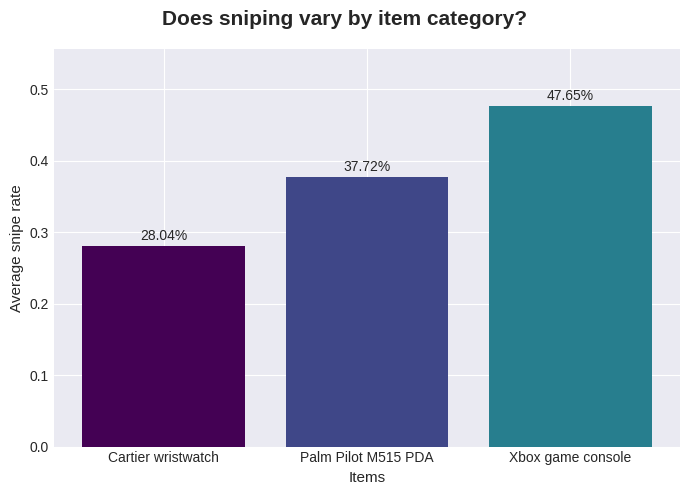

In [49]:
auction_level_df["snipe_rate"] = auction_level_df["n_snipe_bids"] / auction_level_df["n_bids"]
grouped_items_vs_snipe_rate = auction_level_df.groupby("item")["snipe_rate"].mean()


fig3, ax = plt.subplots(figsize=(7, 5))
fig3.suptitle("Does sniping vary by item category?", fontsize=15, fontweight="bold")

bars = ax.bar(
    grouped_items_vs_snipe_rate.index, 
    grouped_items_vs_snipe_rate.values,
    color=PALETTE)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xlabel("Items", fontsize=11)
ax.set_ylabel("Average snipe rate", fontsize=11)
ax.set_ylim(0, grouped_items_vs_snipe_rate.max() + 0.08)

plt.tight_layout()
plt.savefig("../img/03_snipe_rate_by_item.png", dpi=150, bbox_inches="tight")
plt.show()

### Do snipes drive higher prices?
Contrary to initial expectations, auctions won by a snipe bid do not produce higher hammer prices on average ($340 snipe win vs. $388 no snipe). The difference of $48 is modest and likely reflects the item mix rather than a causal effect of sniping itself: higher value Cartier auctions tend to attract more deliberate, non-snipe bidding patterns

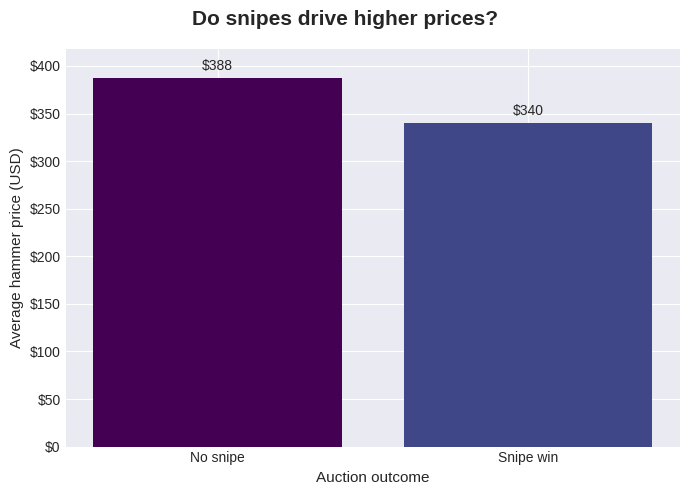

In [50]:
winner_sniper_hammer_price = auction_level_df.groupby("winner_sniped")["hammer_price"].mean()


fig4, ax = plt.subplots(figsize=(7, 5))
fig4.suptitle("Do snipes drive higher prices?", fontsize=15, fontweight="bold")

bars = ax.bar(
    ["No snipe", "Snipe win"], 
    winner_sniper_hammer_price.values,
    color=PALETTE)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_xlabel("Auction outcome", fontsize=11)
ax.set_ylabel("Average hammer price (USD)", fontsize=11)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_ylim(0, winner_sniper_hammer_price.max() + 30)

plt.tight_layout()
plt.savefig("../img/04_snipe_vs_hammer_price.png", dpi=150, bbox_inches="tight")
plt.show()

### Bid timing distribution
The histogram of relative bid time shows a clear and dramatic spike in activity as auctions approach their close. Bidding is otherwise sparse and relatively uniform throughout the auction, which suggests that many participants deliberately wait until the final moments before committing.
This "last minute rush" is a structural feature of the data, not an anomaly.

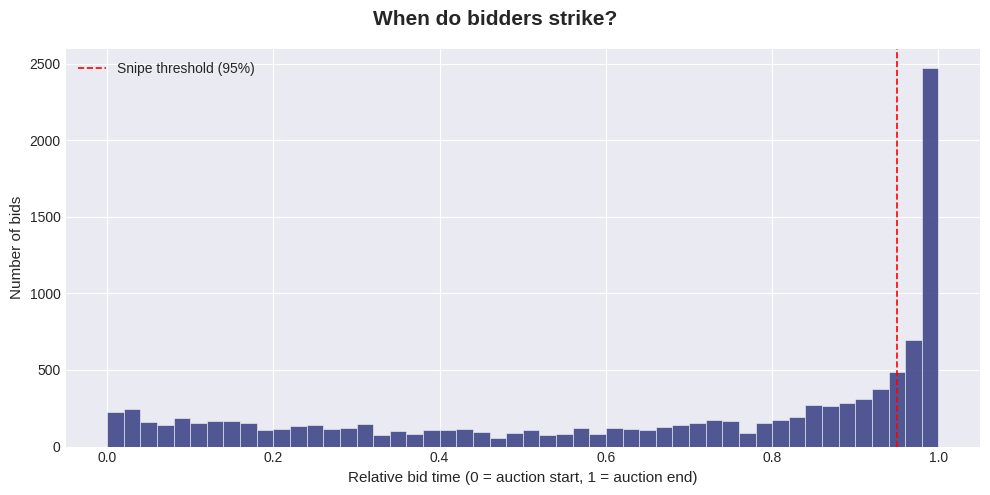

In [51]:
fig5, ax = plt.subplots(figsize=(10,5))
fig5.suptitle("When do bidders strike?", fontsize=15, fontweight="bold")

ax.hist(auction_df_clean["relative_bid_time"], bins=50, color=PALETTE[1], edgecolor="white", linewidth=0.4, alpha=0.9)

ax.axvline(0.95, color="red", linestyle="--", linewidth=1.2, label="Snipe threshold (95%)")

ax.set_xlabel("Relative bid time (0 = auction start, 1 = auction end)", fontsize=11)
ax.set_ylabel("Number of bids", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../img/05_bid_timing_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Price discovery and estimates

Scatter plot of open_bid vs realization_ratio_capped: does a lower opening price correlate with a higher ratio? 

Grouping auctions into opening price bands (low/mid/high) and comparing average n_bidders and hammer_price per band to test "bidding war" hypothesis

## Bidder engagement

Compare mean_bidder_rate and max_bidder_rate by item category:  
 are Cartier bidders more experienced?  

Check if higher winner_bidder_rate correlates with higher realization_ratio:  
 do experienced bidders drive prices up or are they more disciplined?